In [1]:
from sklearn.model_selection import GridSearchCV
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate

X , y = load_iris(return_X_y=True, as_frame=False)

In [2]:
from sklearn.model_selection import KFold, ShuffleSplit

# NOTE: change `n_splits` to a lower number (e.g., 5) for demonstration and debugging!
outer_cv = KFold(n_splits=10, shuffle=True, random_state=42)
inner_cv = ShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

results = {}

In the next cell, we do all the steps described in the previous notebook, for Random Forest.
We then save the results in a dict.

In [3]:
RF_param_grid = {
    "n_estimators": [10, 50, 100],
    "criterion": ["gini", "entropy"],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10]
}

RF = GridSearchCV(
    estimator = RandomForestClassifier(),
    param_grid = RF_param_grid,
    cv = inner_cv,
    return_train_score=True
)
RF_scores = cross_validate(RF, X, y, cv=outer_cv, return_train_score=True, return_estimator=True)

results["RF"] = RF_scores

THe above procedure can be repeated for more estimators.

The splits will be exactly the same, if we pass the same cv split objects, and therefore the comparison is fair

In [4]:
from sklearn.ensemble import GradientBoostingClassifier

GB_param_grid = {
    "n_estimators": [10, 50, 100],
    "learning_rate": [0.01, 0.1, 0.2],
    "max_depth": [3, 5, 7],
    "min_samples_split": [2, 5, 10]
}

GB = GridSearchCV(
    estimator=GradientBoostingClassifier(),
    param_grid=GB_param_grid,
    cv=inner_cv
)
GB_scores = cross_validate(GB, X, y, cv=outer_cv, return_train_score=True, return_estimator=True)

results["GB"] = GB_scores

Add other cells like the above to include more models in the comparison, namely:
- `DecisionTreeClassifier`
- `KNeighborsClassifier`
- `SVC`
- ` MLPClassifier`
- ...

For each, define a sensible grid of hyperparameters

## Side note on the fitting times...
Note: the `fit_time` refers to the entire `GridSearchCV` object:

In [5]:
results["RF"]["fit_time"]

array([2.31696415, 2.31005812, 2.29467988, 2.24700284, 2.26187706,
       2.30022502, 2.2664299 , 2.26675582, 2.2623179 , 2.28585005])

wheras, if we save the estimators, we can acces the `refit_time_` attribute of the `GridSearchCV`

In [6]:
results["RF"]['estimator'][0].refit_time_

0.00599980354309082

## Combine the results
In the following cell, we create a single dataframe containing some quantities of interest

In [7]:
import pandas as pd

data = []
for model, scores in results.items():
    for fold in range(len(scores['test_score'])):
        data.append({
            "fold": fold,
            "model": model, 
            "test_score":scores['test_score'][fold],
            "train_score":scores['train_score'][fold],
            "fit_time": scores['estimator'][fold].refit_time_
        })

df = pd.DataFrame(data)

df

,fold,model,test_score,train_score,fit_time
0,0,RF,1.000000,0.992593,0.006000
1,1,RF,1.000000,1.000000,0.053490
2,2,RF,1.000000,1.000000,0.026987
3,3,RF,0.933333,0.992593,0.005617
4,4,RF,1.000000,0.985185,0.027078
5,5,RF,0.866667,0.992593,0.005732
6,6,RF,0.866667,1.000000,0.005940
7,7,RF,1.000000,1.000000,0.005786
8,8,RF,0.933333,1.000000,0.005812
9,9,RF,0.933333,1.000000,0.028436


This dataframe can be used with `seaborn` plotting library to obtain beautiful boxplots

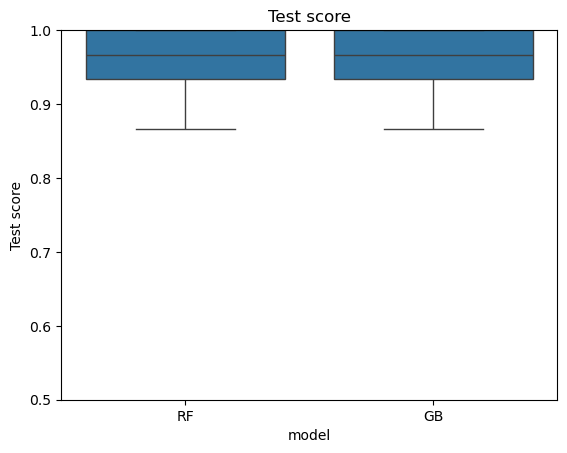

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df, x="model", y="test_score")
plt.title("Test score")
plt.ylabel("Test score")
plt.ylim((0.5, 1.0))
plt.show()

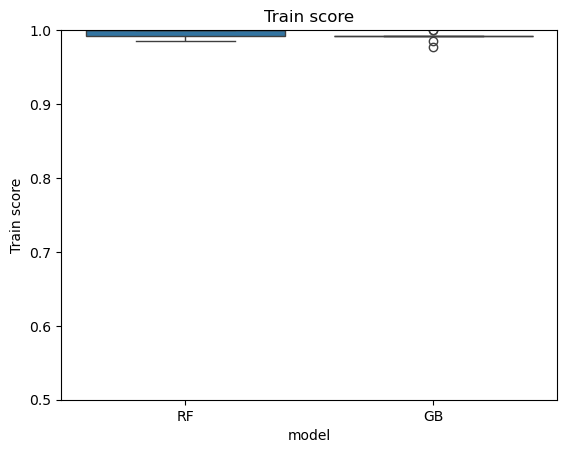

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df, x="model", y="train_score")
plt.title("Train score")
plt.ylabel("Train score")
plt.ylim((0.5, 1.0))
plt.show()

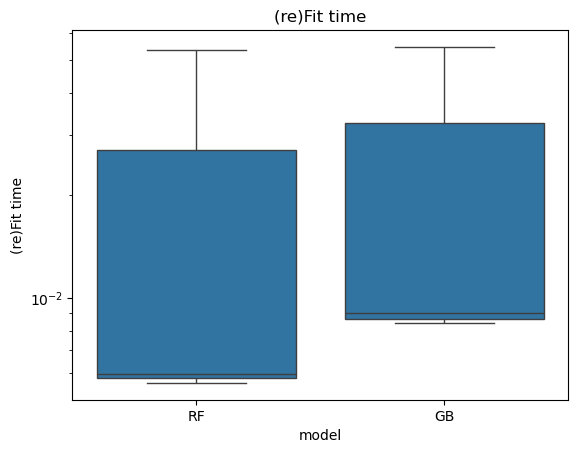

In [10]:
sns.boxplot(data=df, x="model", y="fit_time")
plt.title("(re)Fit time")
plt.ylabel("(re)Fit time")
plt.yscale("log")
plt.show()

You don't have to use boxplots, other plotting options are available as well (have a look at the gallery: https://seaborn.pydata.org/examples/index.html)

For example, violin plots are a good alternative:

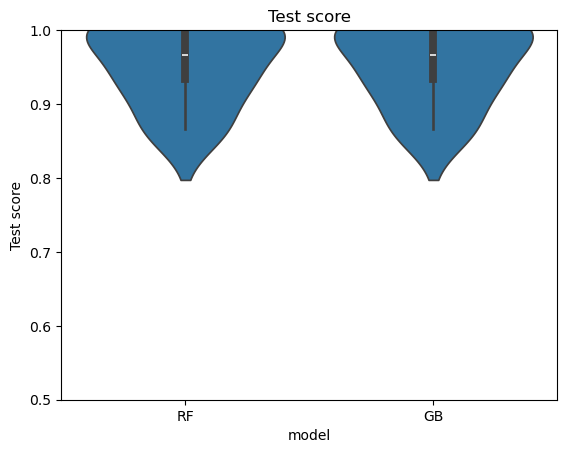

In [11]:
sns.violinplot(
    data=df, 
    x="model", 
    y="test_score",
    fill=True,
    )
plt.title("Test score")
plt.ylabel("Test score")
plt.ylim((.5, 1.))
plt.show()